In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm

import time
from datetime import date

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

# provides interactive "R studio-like" view of dataframes
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

# ensures function files are visible: can use 'src.loading' for example
sys.path.append(os.path.abspath(".."))

In [2]:
from src.loading import load_data
# ------------------- Spatial Generalization 3.0 m/s
df = load_data("../data/spatial_generalization/spatial_generalization_3m.parquet", keep_col='training_status')
# # drop every row from participant p007
df = df[df['ppid'] != 'p007'].copy()

# ------------------- Spatial Generalization 2.0 m/s
#df = load_data("../data/target_trial_spatial_generalization.parquet", keep_col='training_status')

df_full = df.copy()

In [5]:

# fix water_speed_binary if needed
from pandas.api.types import is_integer_dtype

if not is_integer_dtype(df_full['water_speed_binary']):

    print('water_speed_binary is acting strange: Implementing fix...')
    
    df_full['water_speed_binary2'] = (df_full['water_speed_m_s'] != 0.0).astype(int).copy()
    df_full['water_speed_binary'] = df_full['water_speed_binary2'].copy()
    
    # drops redundant col
    df_full.drop(columns=['water_speed_binary2'], inplace=True)
    


# add new variables

df_full['lateral_error_x'] = (df_full['min_pos_from_target_x'] - df_full['target_position_x']) # 
df_full['depth_error_z'] = (df_full['min_pos_from_target_z'] - df_full['target_position_z']) 

# convert key columns to cm:
from src.convert_to_cm import convert_to_cm

df_labeled = convert_to_cm(df_full,
              cols=[
                    'min_pos_from_target_x',
                    'min_pos_from_target_z',
                    'target_position_x',
                    'target_position_z',
                    'lateral_error_x',
                    'depth_error_z'
                   ])

print('res:', df_labeled['target_position_x'].dtypes)

# label ppid by water speed
from src.label_water_speed_ppid import label_water_condtion_ppid
df_labeled = label_water_condtion_ppid(df_labeled, ppid_col='ppid', water_col='water_speed_m_s', selected_speeds=[-3.0,-2.0,0.0]).copy() 
# one-dimensional errors - in cm
#df_labeled['lateral_error_x_cm'] = (df_labeled['min_pos_from_target_x'] - df_labeled['target_position_x']) * 100 # convert to cm
#df_labeled['depth_error_z_cm'] = (df_labeled['min_pos_from_target_z'] - df_labeled['target_position_z']) * 100

# order targets

# adjust target label
target_mapping = {
    "p0.6": "R60",
    "p0.3": "R30",
    "neg0.3": "L30",
    "neg0.6": "L60"
}
df_labeled['target_x_label'] = df_labeled['target_x_label'].map(target_mapping).copy()

from src.features import order_targets
df_labeled['target_position_x'] = order_targets(df_labeled.copy())
df_labeled['target_x_label'] = order_targets(df_labeled.copy())

print(df_labeled.columns.to_list())
df_labeled['signed_euclidean_cm'] = df_labeled['ball_dist_to_center_cm'] * np.sign(df_labeled['lateral_error_x_cm'])



df_labeled['set_order'] = df_labeled['set_order'].replace({
    '1': '63_36',
    '2': '36_63'
}).copy()

# ensures PCA compatibility
df_labeled['water_speed_m_s'] = df_labeled['water_speed_m_s'].replace(0.0, 0.0001).copy()


# add temporal phase label categorical varible
from src.add_phases import label_phases, df_add_phases
phases = label_phases() 

df_labeled = df_add_phases(df_labeled, phase_array=phases).copy()


from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label',
                       ).copy()

# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')



water_speed_binary is acting strange: Implementing fix...
res: float64
0       R30
1       R60
2       L30
3       L60
4       R60
       ... 
7386    R60
7387    R30
7388    L60
7389    L30
7390    R60
Name: target_x_label, Length: 7391, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
0       R30
1       R60
2       L30
3       L60
4       R60
       ... 
7386    R60
7387    R30
7388    L60
7389    L30
7390    R60
Name: target_x_label, Length: 7391, dtype: category
Categories (4, object): ['L60' < 'L30' < 'R30' < 'R60']
['experiment', 'ppid', 'session_num', 'trial_num', 'block_num', 'trial_num_in_block', 'start_time', 'end_time', 'hand', 'target_hit', 'final_ball_state', 'type', 'target_position_x', 'target_position_y', 'target_position_z', 'target_width', 'launch_direction', 'before_launch_velocity_x', 'before_launch_velocity_z', 'before_launch_speed', 'before_launch_angle', 'current_force', 'water_inertia', 'water_speed_m_s', 'launch_angle', 'launch_Speed', '

C:\Users\jacob\AppData\Local\Temp\ipykernel_20044\738862041.py:63: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_labeled['set_order'] = df_labeled['set_order'].replace({
C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\add_cycles.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or

crossed_threshold
True     6815
False     196
Name: count, dtype: int64
count                                                  7011
unique                                                 7011
top       0.000000_0.023777_0.047277_0.070504_0.093465_0...
freq                                                      1
Name: ball_pos_z, dtype: object


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [15]:
df_labeled.columns

Index(['experiment', 'ppid', 'session_num', 'trial_num', 'block_num',
       'trial_num_in_block', 'start_time', 'end_time', 'hand', 'target_hit',
       'final_ball_state', 'type', 'target_position_x', 'target_position_y',
       'target_position_z', 'target_width', 'launch_direction',
       'before_launch_velocity_x', 'before_launch_velocity_z',
       'before_launch_speed', 'before_launch_angle', 'current_force',
       'water_inertia', 'water_speed_m_s', 'launch_angle', 'launch_Speed',
       'slow_counter', 'ball_pos_x', 'ball_pos_z', 'ball_time',
       'ball_dist_from_target', 'closest_center_ball_pos_x',
       'closest_center_ball_pos_z', 'final_ball_pos_x', 'final_ball_pos_z',
       'turning_absolute_x', 'turning_absolute_y', 'distance_from_target',
       'min_pos_from_target_x', 'min_pos_from_target_z', 'total_score',
       'step_0_time', 'step_1_time', 'step_2_time', 'ball_dist_to_center_cm',
       'water_speed_binary', 'target_angle_90', 'launch_deviation',
       'la

In [9]:
### SPEED 2.0 Trial Schedule

In [7]:
from src.add_phases import label_phases, df_add_phases

assert (~df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=10,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_1',
                                   'washout_ST_1',
                                   'retention_ST_1',
                                    'washout_ST_2',
                                     'retention_ST_2',
                                   'washout_AT_1',
                                   'training_2',
                                    'washout_AT_2'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,282,286,290,294,310,374]),
                        trial_hi = np.array([20,52,277,281,285,289,293,309,373,385])
)

from src.plotting import plot_trial_schedule
#g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)

from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label'
                       ).copy()
df_labeled


AssertionError: Ensure you selected the correct data.

In [ ]:
### SPEED 3.0 Trial Schedule

In [11]:
from src.add_phases import label_phases, df_add_phases

assert (df_labeled['experiment'].str.startswith('novel')).all(),  "Ensure you selected the correct data."

phases = label_phases(n_phases=7,
                      phase_names = ['familiarization',
                                   'baseline',
                                   'training_1',
                                   'washout_ST',
                                   'washout_1_AT',
                                   'training_2',
                                   'washout_2_AT'])

df_labeled = df_add_phases(df_labeled, 
                           phase_array=phases,
                          trial_lo = np.array([1,21,53,278,294,310,374]),
                        trial_hi = np.array([20,52,277,293,309,373,389])
)

from src.plotting import plot_trial_schedule
#g = plot_trial_schedule(df_labeled, y_col='water_speed_binary', context='poster', font_scale=3)

from src.add_cycles import add_cycles
df_labeled = add_cycles(df_labeled,
                       n_trials=4,
                       ppid_col='ppid_full',
                       target_col='target_x_label'
                       ).copy()


C:\Users\jacob\water_current_MA\src\add_phases.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['phase_target_trial_num'] = df.groupby(['ppid_full', 'phase', 'target_x_label']).cumcount() + 1
C:\Users\jacob\water_current_MA\src\add_cycles.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df.groupby(grouping_vars).cumcount()
C:\Users\jacob\water_current_MA\src\add_cycles.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default a

In [13]:
# filter out familiarization (i.e, starts with an 'f')
df_nf = df_labeled[~df_labeled['phase'].str.startswith('f')].copy()

# remove trials that do not cross a certain threshold in the z-plane (i.e, trials that did not exceed 70 cm in the z-plane)
from src.cleaning import crossed_threshold

# make column checking if ball crossed 70.0 cm on z axis
df_nf['crossed_threshold'] = df_nf.apply(
    lambda row: crossed_threshold(row, col="ball_pos_z", val=0.70), # 70 cm
        axis=1
).copy()
# check
print(df_nf['crossed_threshold'].value_counts())
print(df_nf['ball_pos_z'].describe())

# Make a seperate df without trials that did not cross threshold
df_filt = df_nf[df_nf['crossed_threshold']].copy() # retains rows where crossed_threshold == True

# reduce df to key cols
from src.cleaning import extract_key_columns
df_small_filt = extract_key_columns(df_filt).copy()


# check participant counts per group:
from src.features import get_sample_sizes
get_sample_sizes(df_small_filt, group_cols=['speed_label','experiment', 'set_order'], ppid_col='ppid_full')

crossed_threshold
True     6815
False     196
Name: count, dtype: int64
count                                                  7011
unique                                                 7011
top       0.000000_0.023777_0.047277_0.070504_0.093465_0...
freq                                                      1
Name: ball_pos_z, dtype: object


C:\Users\jacob\water_current_MA\src\features.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols).size()


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
print(df_small_filt.columns)
df_small_filt.head()

In [ ]:
### APPLY PCA

C:\Users\jacob\water_current_MA\src\PCA.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_group = data.groupby(group_cols)


Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_target_trial_num', 'trial_num_target', 'global_cycle_num',
       'cycle_target_num', 'cycle_TargetxPhase_num', 'launch_deviation',
       'launch_Speed', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'lateral_error_x_cm', 'depth_error_z_cm', 'target_hit',
       'water_speed_binary', 'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unrotated_z', 'PCA_error_X_cm', 'PCA_error_Z_cm'],
      dtype='object')


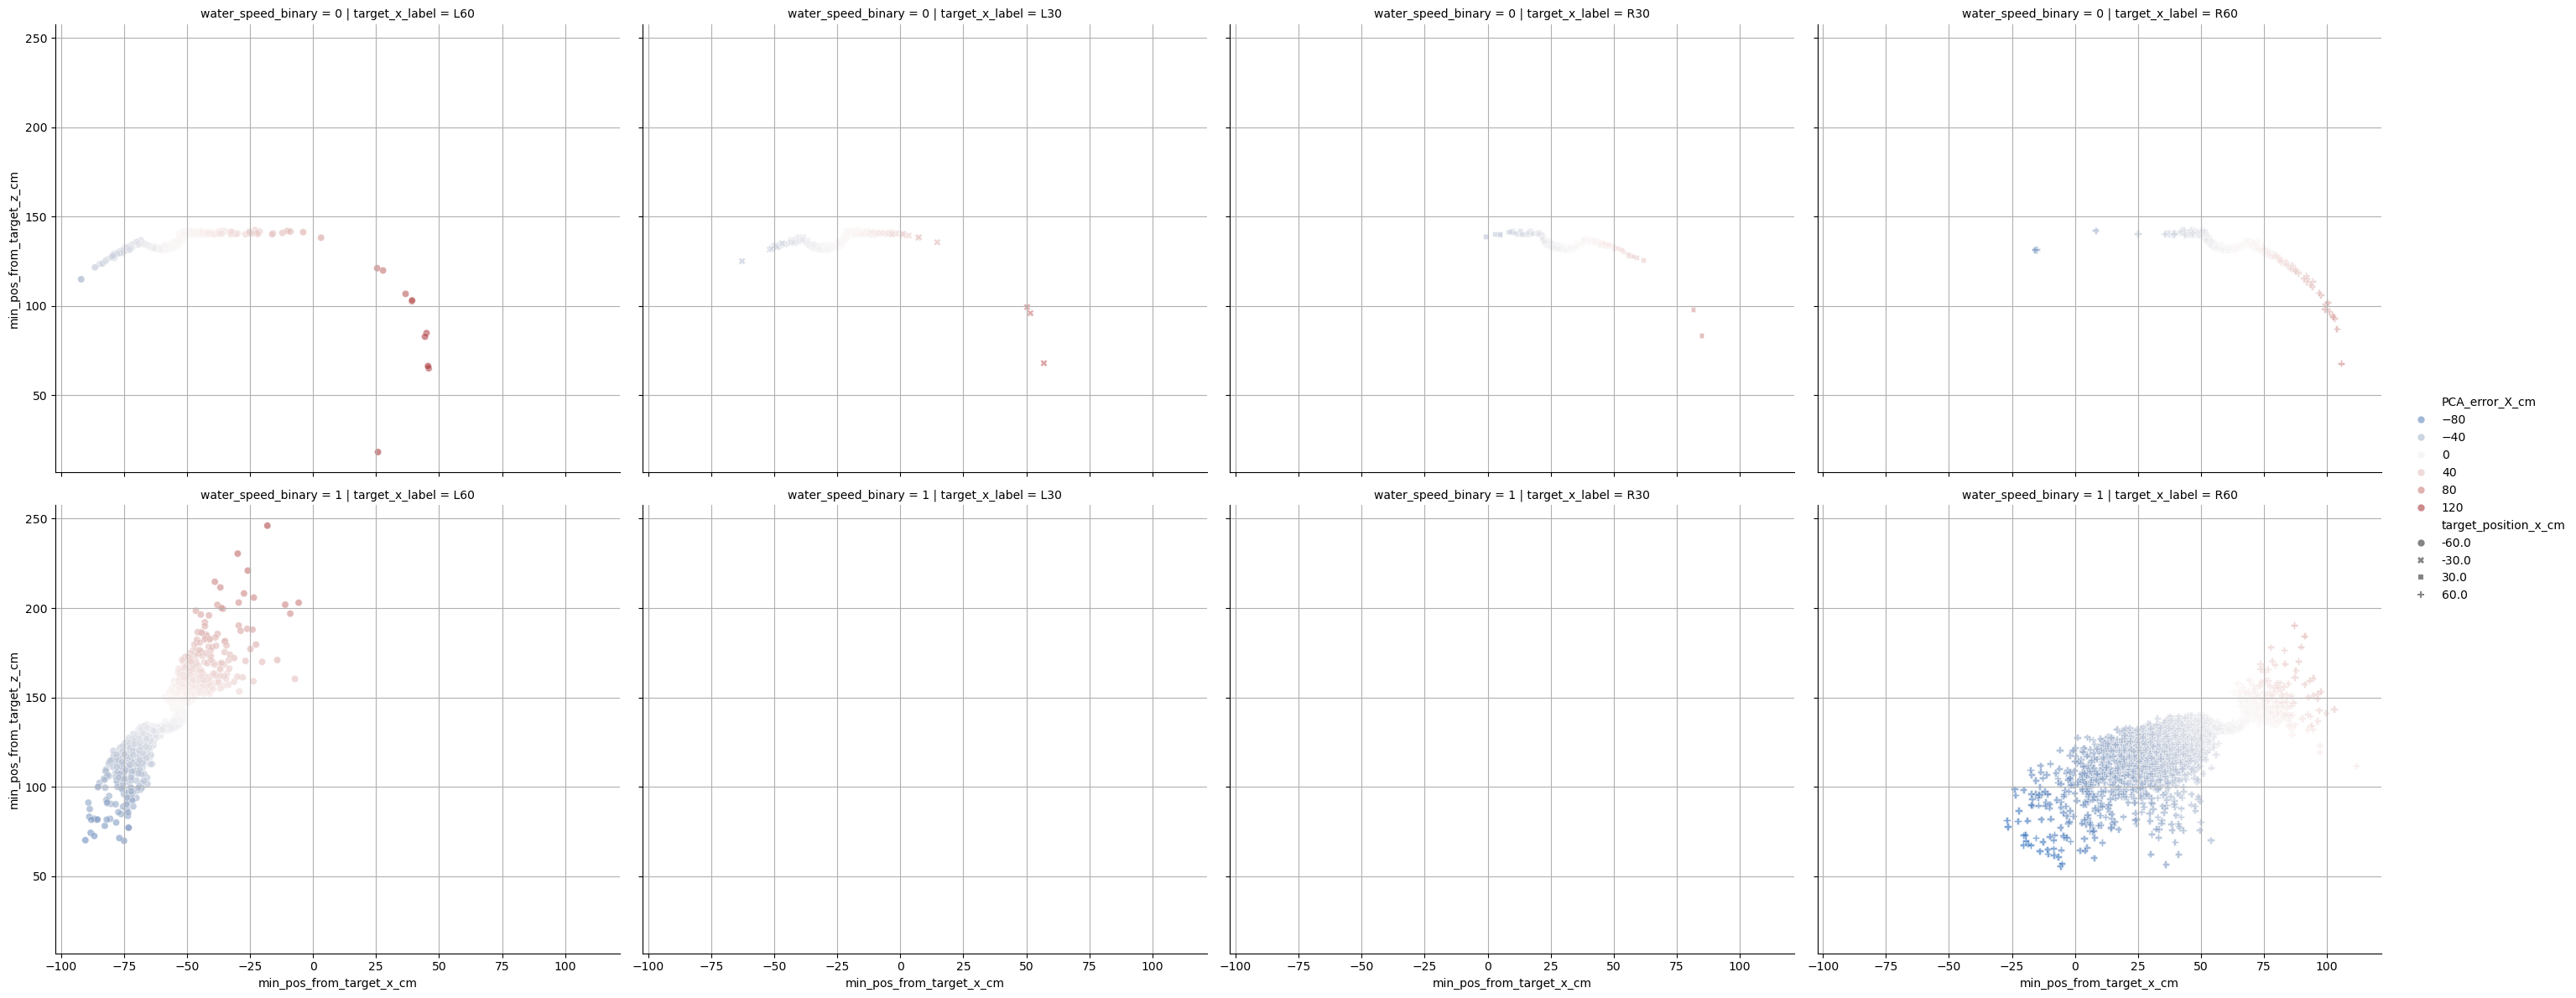

In [15]:
from src.PCA import compute_PCA_summary

PCA_table = compute_PCA_summary(df_small_filt,
            features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
            group_cols = ['water_speed_m_s','set_order','target_position_x_cm'],
            water_col = 'water_speed_m_s',
            n_components=2
            )
PCA_table


# extract relevant columns
PCA_table_small = PCA_table.iloc[:, 0:9].copy()
PCA_table_small


# merge small summary table into raw df with trial-by-trial data
df_angles = df_small_filt.copy()

group_cols = ['water_speed_m_s','set_order','target_position_x_cm']

new_cols = ['pc_vector_1_angle','pc_vector_1_pca_center_x','pc_vector_1_pca_center_z','pc_vector_1_c_X','pc_vector_1_c_Z']

df_angles_v = df_angles.merge(PCA_table_small[group_cols + new_cols], how="left", on=group_cols)

from src.PCA import compute_PCA_error

PCA_error_df = compute_PCA_error(trial_df=df_angles_v,
                  pc_deg='pc_vector_1_angle',
                  target_x_col='target_position_x_cm',
                  target_z_col='target_position_z_cm',
                  features = ['min_pos_from_target_x_cm','min_pos_from_target_z_cm'],
                  water_col = 'water_speed_m_s'
                 )
print(PCA_error_df.columns)

PCA_error_df


# Visualization of diagonal error
g = sns.relplot(
    data=PCA_error_df, 
    x='min_pos_from_target_x_cm', 
    y='min_pos_from_target_z_cm',
    hue='PCA_error_X_cm', 
    style='target_position_x_cm',
    col='target_x_label',  
    row='water_speed_binary',
    palette='vlag',            
    alpha=0.6,
    kind='scatter',
    height=6,
    aspect=1.2
)

# Apply grid to all faceted subplots
for ax in g.axes.flat:
    ax.grid(True)

plt.show()

In [29]:
PCA_error_df

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [ ]:
### remove outliers

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

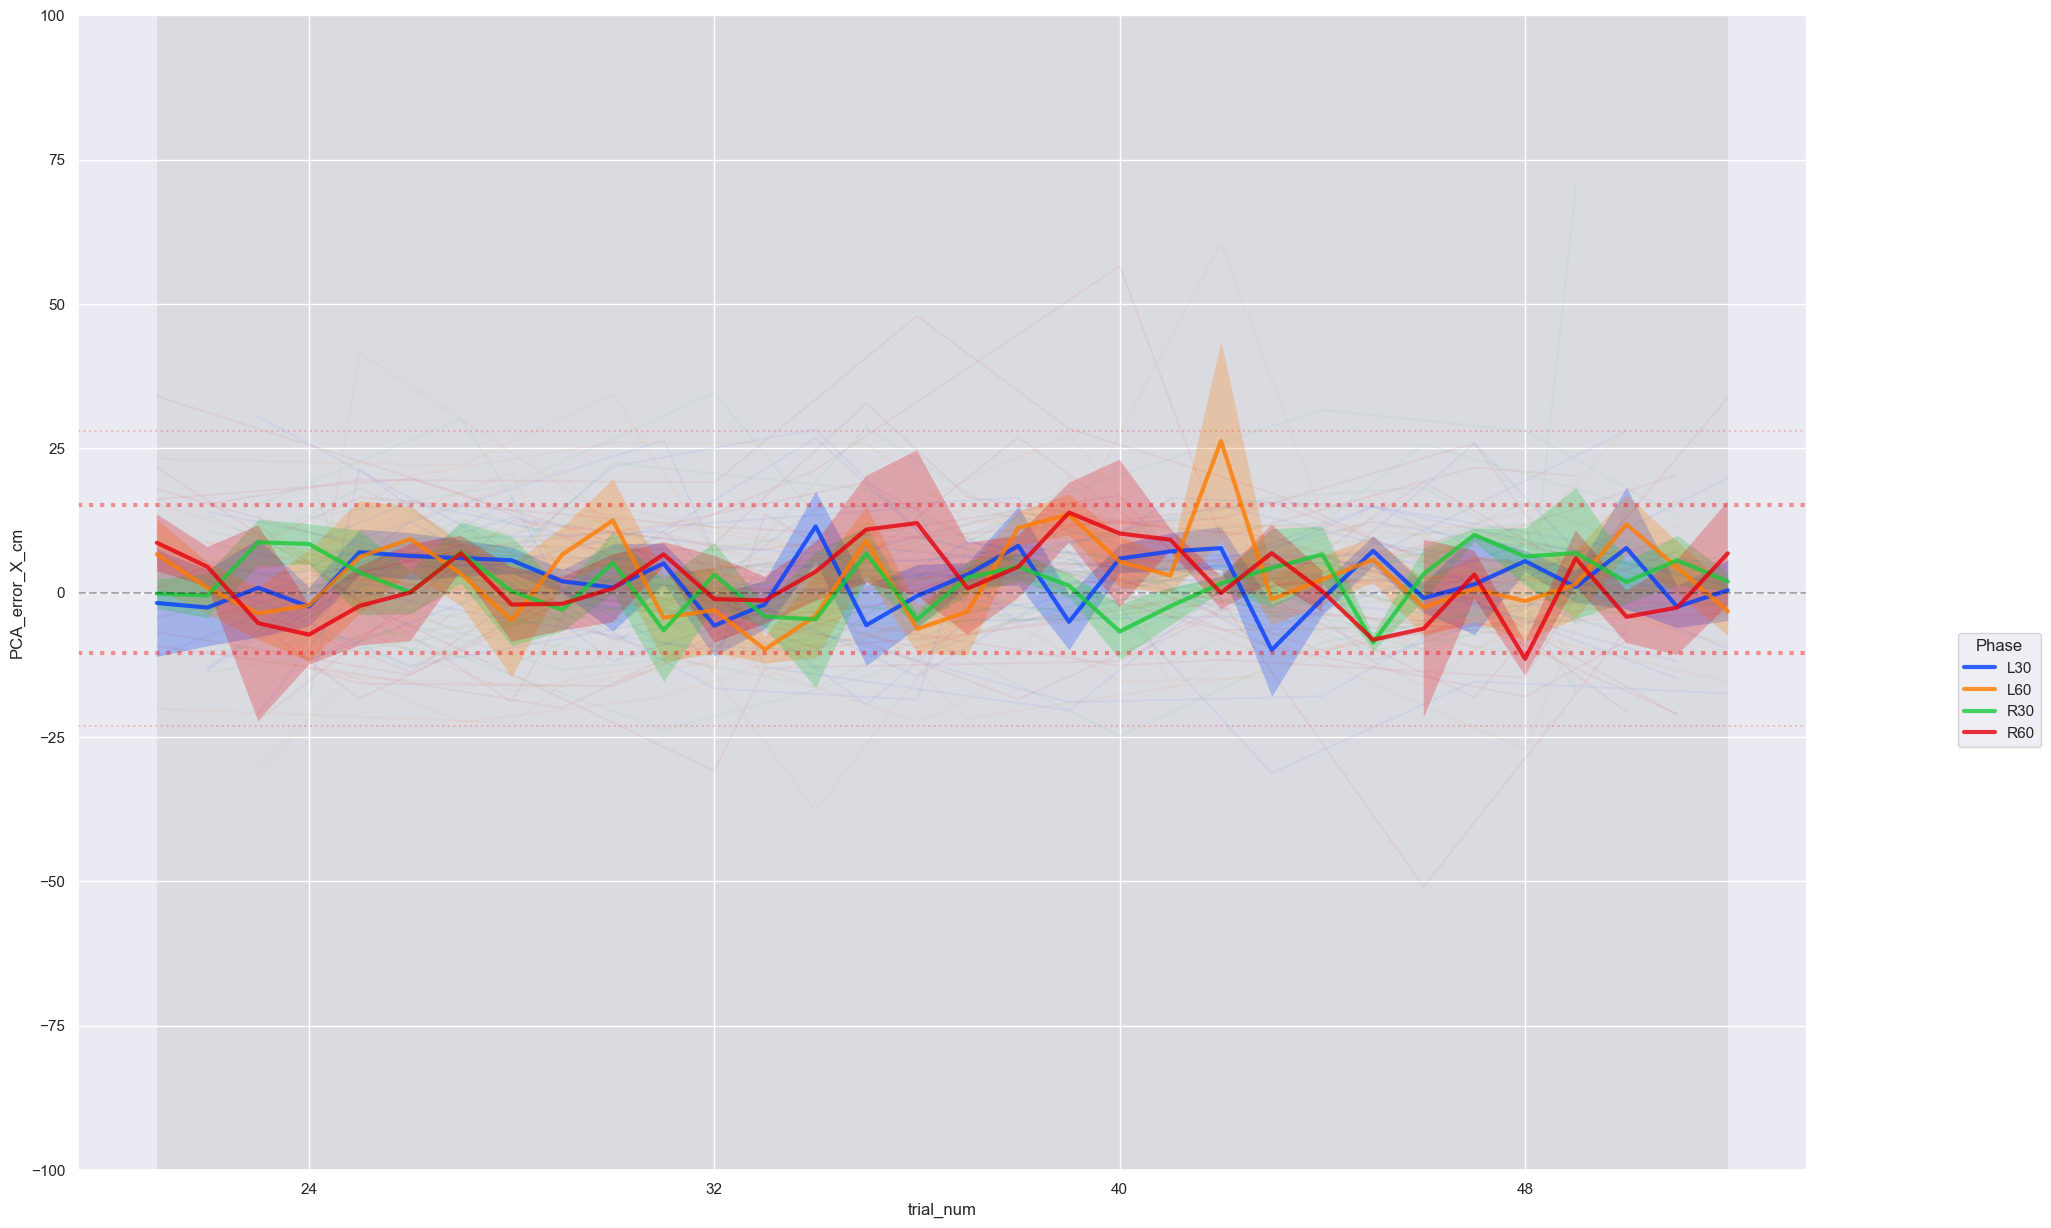

--- Baseline Trial Outlier Removal (PCA_error_X_cm) ---
Trials exceeding absolute threshold of 50.0: 4
Max absolute error remaining in baseline: 47.92081720312379
PCA_error_df (6815, 43)
clean_df (6811, 43)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

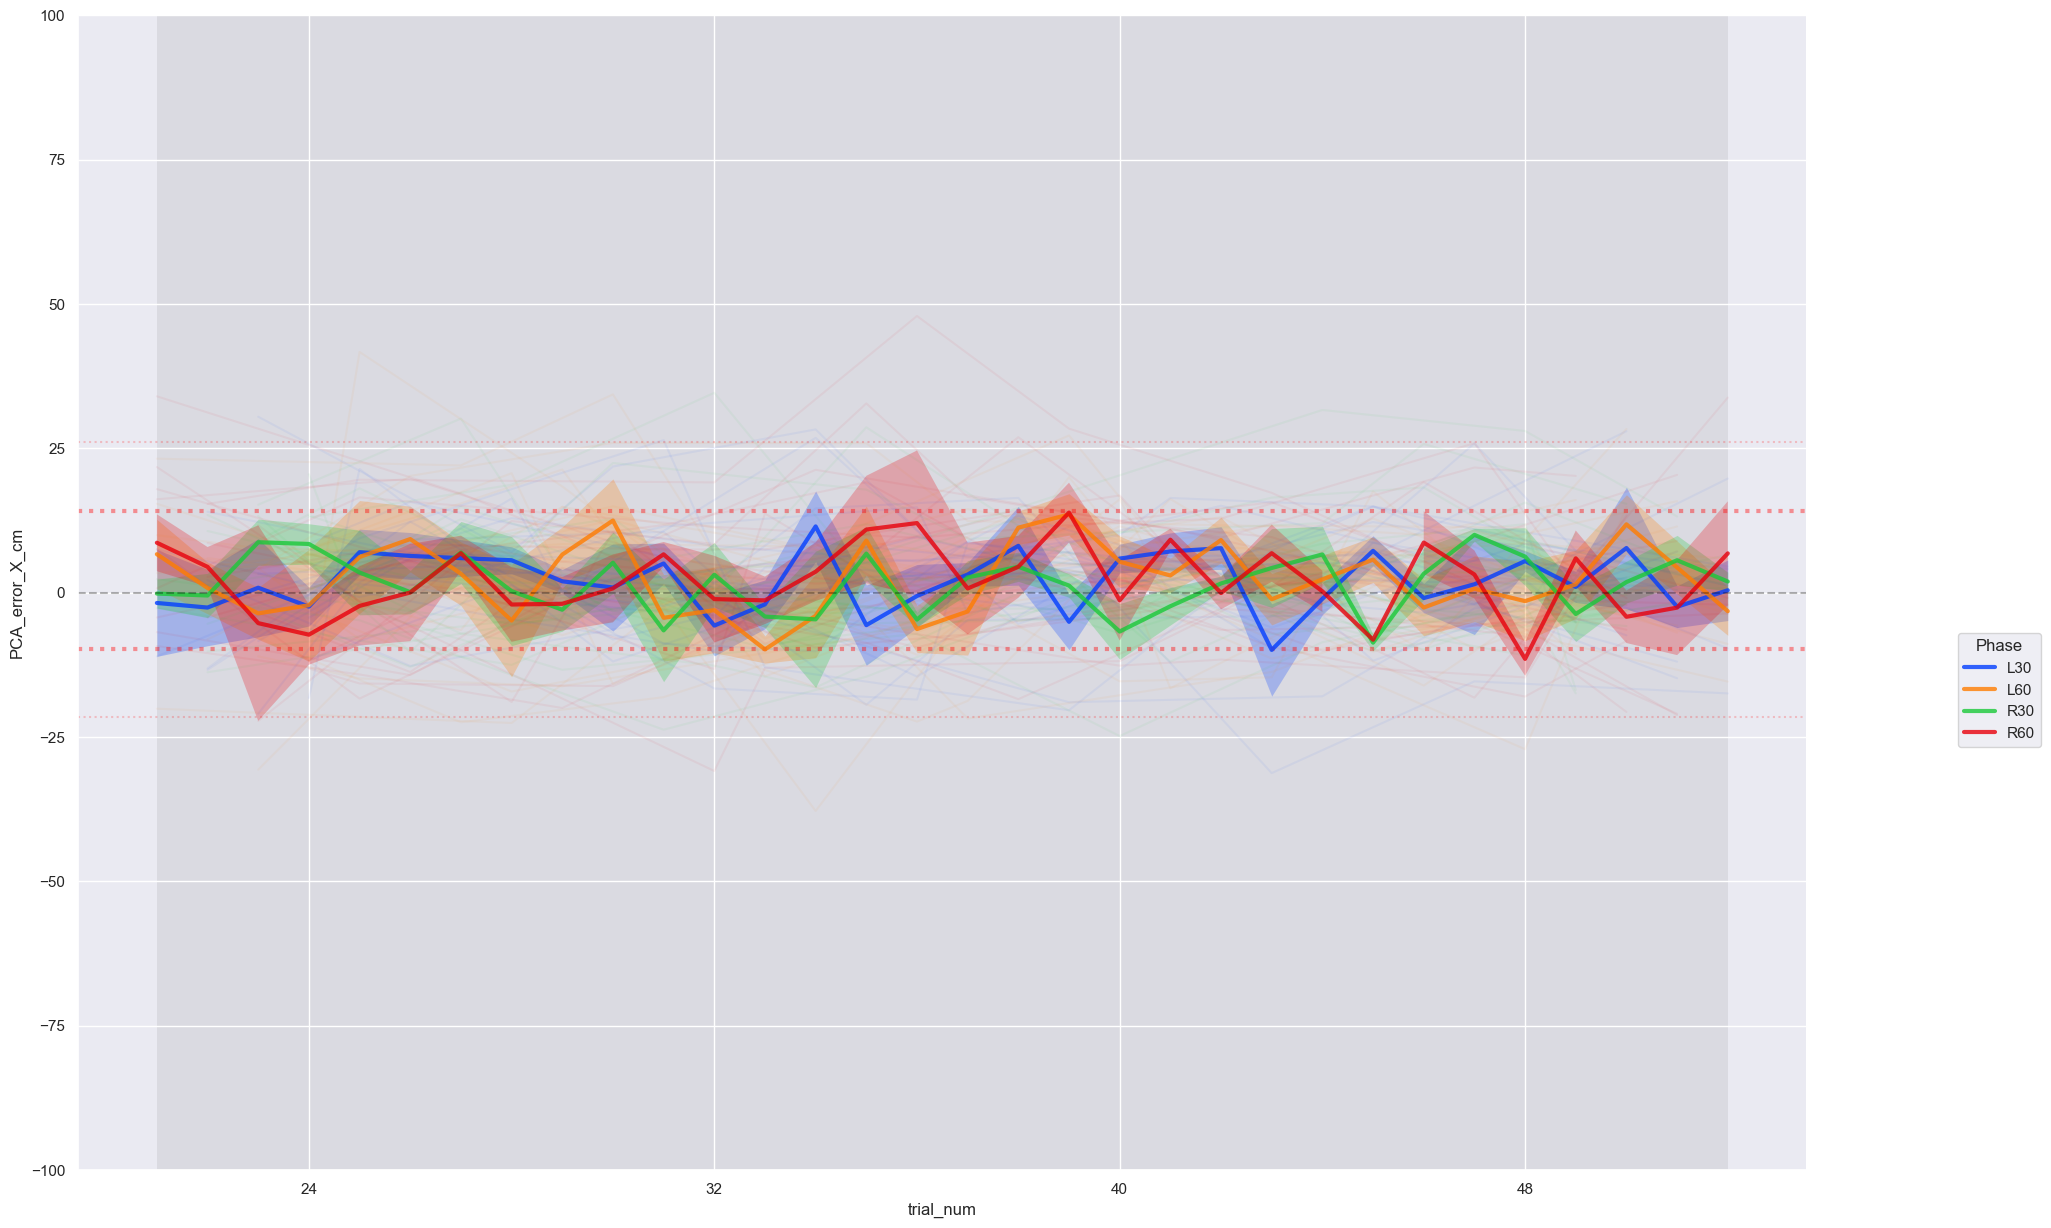

In [17]:

from src.plotting import plot_all_trials

df_baseline = PCA_error_df[PCA_error_df['phase'] == 'baseline']

plot_all_trials(df_baseline, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', # PCA_error_X_cm
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                    show_sd_line=True
                    )


from src.cleaning import remove_baseline_outlier_trials

# tag baseline outlier ppid
clean_df = remove_baseline_outlier_trials(PCA_error_df,
                            y_col='PCA_error_X_cm',
                            trial_col='trial_num'
                               )

print('PCA_error_df', PCA_error_df.shape)
print('clean_df', clean_df.shape)

from src.plotting import plot_all_trials

df_baseline_clean = clean_df[clean_df['phase'] == 'baseline']

plot_all_trials(df_baseline_clean, 
                     col_col =None,
                     row_col=None,
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm', # PCA_error_X_cm
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True,
                     show_sd_line=True
                    )


In [ ]:
# BASELINE CORRECT

In [ ]:
### SAVE PCA OUPUT DF

In [25]:
from src.baseline_correct import baseline_correct

clean_df = clean_df.rename(columns={'lateral_error_x_cm': 'min_x_delta'})


df_bc = baseline_correct(data = clean_df,
                phase_col = 'phase',
                baseline_string='baseline',
                y_col='unrotated_x',
                PCA_col='PCA_error_X_cm'# lateral_error_x_cm, PCA_error_X_cm
                ) 
df_bc

# Extract and join unique experiment strings
unique_exps = df_bc['experiment'].unique().astype(str)
exp_tags = "_".join(unique_exps[:2]) 
if len(unique_exps) > 2:
    exp_tags += "_etc"
    
# Extract unique water speeds, rounded to prevent floating point noise
speeds = df_bc['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\spatial_generalization\\{file_name}"

df_bc.to_csv(file_path, index=False)
print(f"Saved: {file_path}")
print(df_bc.columns)





from src.early_late_exposure import early_late_phase

df_tmp = df_bc.copy()

early_late_phase_df = early_late_phase(df_tmp,
                                       group_cols=['ppid_full'],
                                       phase_col='phase',
                                       phases_to_keep=['training_1','training_2'],
                                       trial_col='phase_target_trial_num', 
                                       n_trials=4
                                      ).copy()

# Extract and join unique experiment strings
exp_tags = "_".join(early_late_phase_df['experiment'].unique().astype(str))

# Extract unique water speeds, rounded to prevent floating point noise
speeds = early_late_phase_df['water_speed_m_s'].unique()
speed_tags = "_".join([str(round(s, 1)).replace('-', 'neg').replace('.', '_') for s in np.sort(speeds)])

# construct the combined filename
file_name = f"early_late_phase_PCA_error_{exp_tags}_speed_{speed_tags}.csv"
file_path = f"..\\data\\spatial_generalization\\{file_name}"

early_late_phase_df.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

C:\Users\jacob\water_current_MA\src\baseline_correct.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_baseline = df_filtered.groupby(grouping_vars)[y_col].agg(['mean', 'median']).reset_index()
C:\Users\jacob\water_current_MA\src\baseline_correct.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  assert np.isclose(df_merged[check_mask].groupby(grouping_vars)[f"{y_col}_median_bc"].median(), 0, atol=1e-8).all(), \
C:\Users\jacob\water_current_MA\src\baseline_correct.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=

Saved: ..\data\spatial_generalization\PCA_error_novel_TU_3.0M_spatial_generalization_novel_TD_3.0M_spatial_generalization_speed_neg3_0_0_0.csv
Index(['experiment', 'ppid_full', 'speed_label', 'target_x_label',
       'target_position_x_cm', 'target_position_z_cm', 'trial_num', 'phase',
       'phase_target_trial_num', 'trial_num_target', 'global_cycle_num',
       'cycle_target_num', 'cycle_TargetxPhase_num', 'launch_deviation',
       'launch_Speed', 'ball_dist_to_center_cm', 'signed_euclidean_cm',
       'min_x_delta', 'depth_error_z_cm', 'target_hit', 'water_speed_binary',
       'water_speed_m_s', 'sign_label', 'set_order',
       'min_pos_from_target_x_cm', 'min_pos_from_target_z_cm',
       'target_angle_90', 'pc_vector_1_angle', 'pc_vector_1_pca_center_x',
       'pc_vector_1_pca_center_z', 'pc_vector_1_c_X', 'pc_vector_1_c_Z',
       'pc_rad', 'centered_x', 'centered_z', 'unrotated_x', 'unrotated_z',
       'tgt_centered_x', 'tgt_centered_z', 'tgt_unrotated_x',
       'tgt_unro

C:\Users\jacob\water_current_MA\src\early_late_exposure.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_max = df.groupby(group_cols + [phase_col])[trial_col].transform('max')


In [27]:
early_late_phase_df

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(*plot_args, **

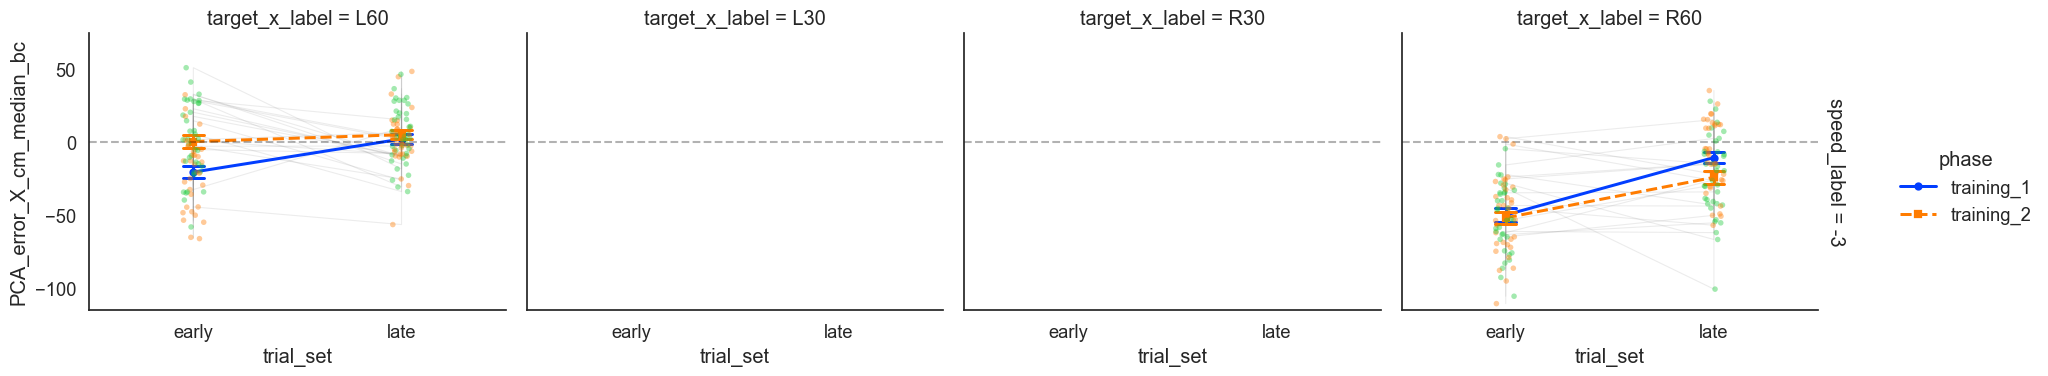

In [29]:
from src.plotting import plot_early_late_exposure

plot_early_late_exposure(early_late_phase_df,
                         x_col='trial_set',
                         y_col='PCA_error_X_cm_median_bc', #PCA_error_X_cm_mean_bc
                         ylim=(-115,75),
                         line_col='speed_label',
                         cond_col='phase', 
                         ppid_col='ppid_full',
                         facet_row='speed_label',
                         facet_col='target_x_label',
                         show_zero_line=True)

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, unit_data in sub_data.groupby("units"):
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\relational.py:313: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

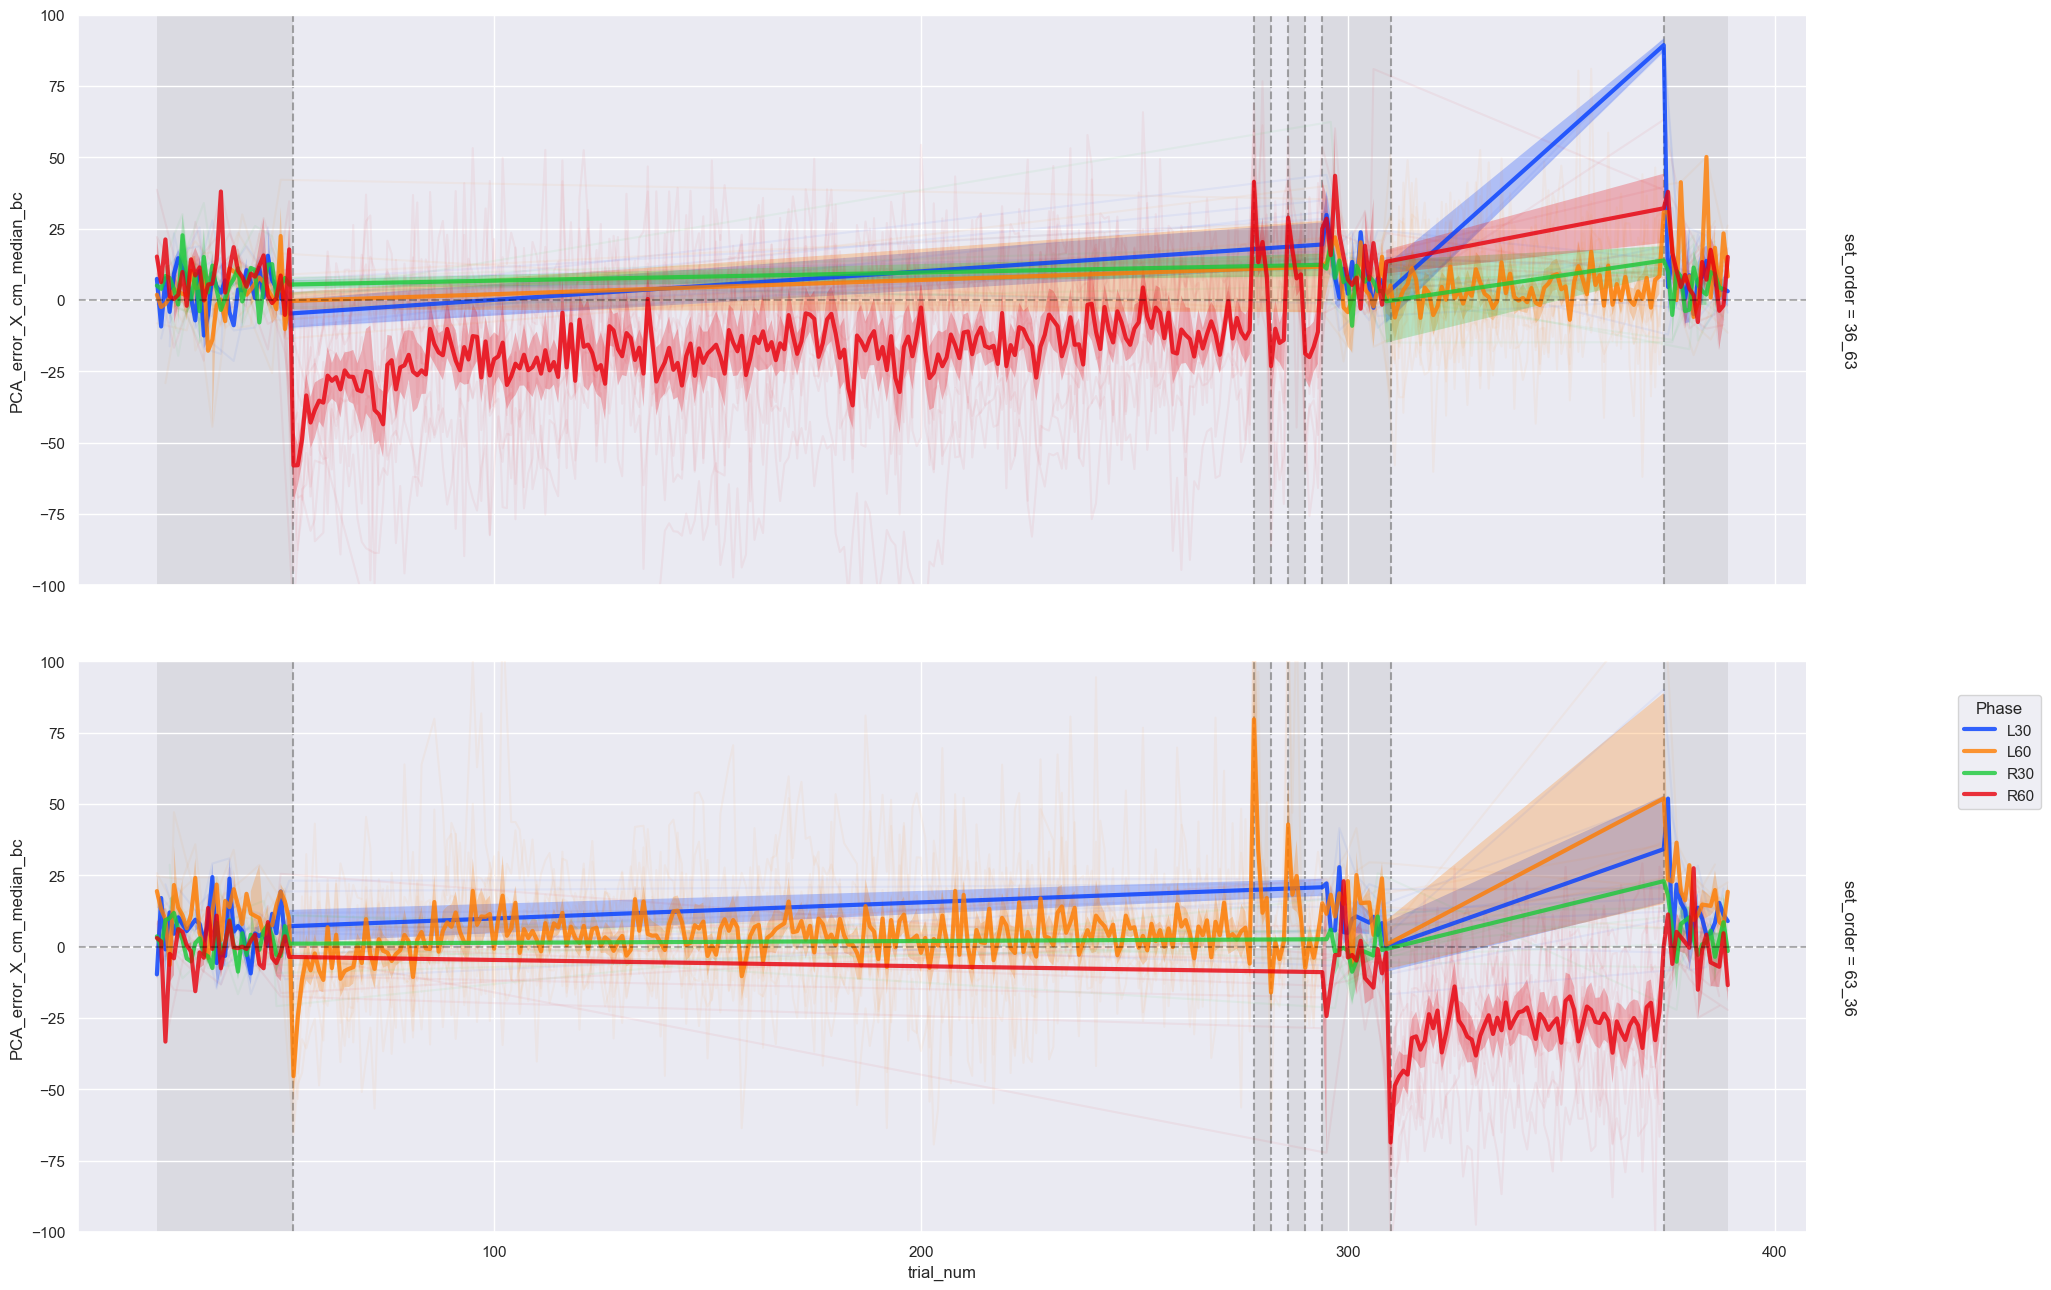

In [33]:
from src.plotting import plot_all_trials

plot_all_trials(df_bc, 
                     col_col =None,
                     row_col='set_order',
                     cond_col='phase',
                     ppid_col='ppid_full',
                     target_col='target_x_label',
                     y_col = 'PCA_error_X_cm_median_bc', 
                     x_col='trial_num',
                     context='poster', 
                     transition_col='water_speed_binary',
                     font_scale=3,
                     marker_size=1.5,
                     estimator='mean',
                     y_lim=(-100,100),
                     show_zero_line=True
                    )




In [61]:
len(PCA_error_df['trial_num'])

6897

C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
C:\Users\jacob\anaconda3\envs\water_current_project\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(*plot_args, **

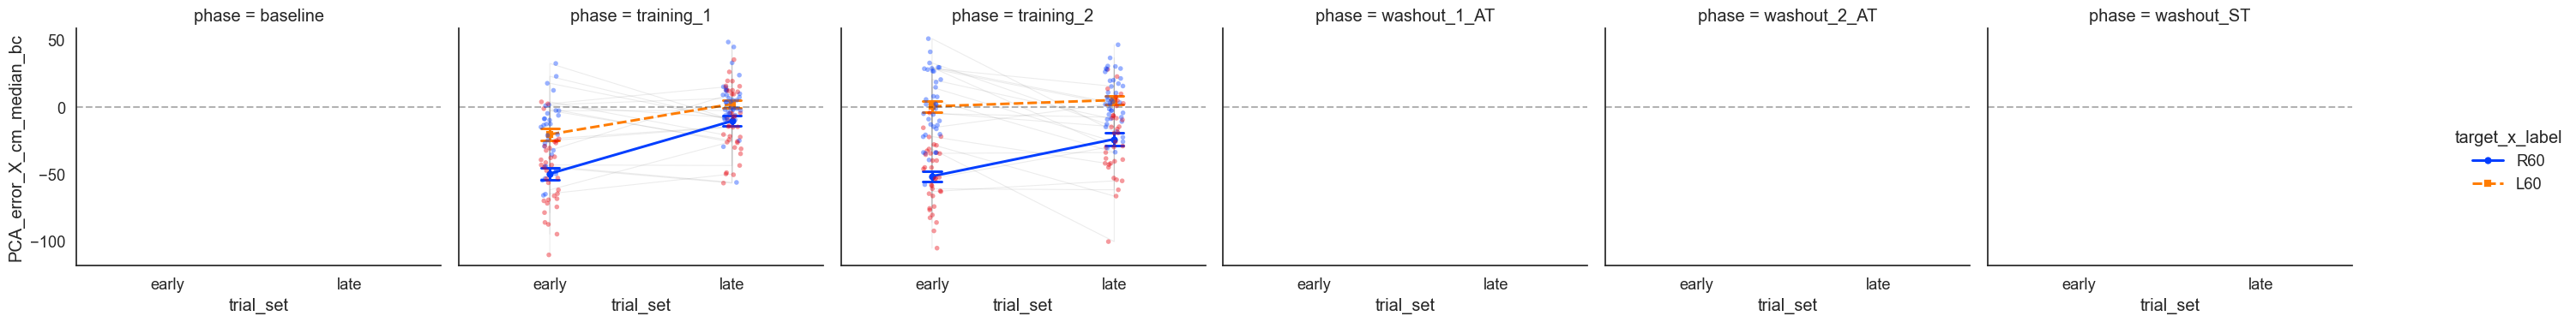

In [37]:

from src.plotting import plot_early_late_exposure


plot_early_late_exposure(early_late_phase_df,
                            cond_col='target_x_label', 
                            ppid_col='ppid_full',
                            y_col='PCA_error_X_cm_median_bc',
                            x_col='trial_set',
                            line_col ='set_order',
                            facet_row = None,
                            facet_col = 'phase',
                             show_zero_line=True)
#plot_early_late_exposure(early_late_10_means_dev)
#plot_early_late_exposure(early_late_10_means_speed)